In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
import os

sys.path.append('..')
sys.path.append(os.path.abspath(os.path.join('..', 'magnet-pinn')))

In [4]:
import torch

from torch.utils.data import DataLoader

from magnet_pinn.data.transforms import Compose, Crop, GridPhaseShift
from magnet_pinn.data.grid import MagnetGridIterator

VAL_DIR = "../data/processed/batch_17/grid_voxel_size_4_data_type_float32"

augmentation = Compose(
    [
        Crop(crop_size=(100, 100, 100)),
        GridPhaseShift(num_coils=8)
    ]
)

val_set = MagnetGridIterator(VAL_DIR, transforms=augmentation, num_samples=2)
val_loader = DataLoader(val_set, batch_size=1, num_workers=2)

In [ ]:
import einops

from mrifield.models import UNet3D
from mrifield.train.lit_mrifield import LitMRIField
from magnet_pinn.utils import StandardNormalizer

CKPT = "baseline_unet/qvnx449u/checkpoints/epoch=9-step=173750.ckpt"

model = UNet3D(in_channels=5, out_channels=12)

train_input_normalizer = StandardNormalizer.load_from_json("../results/normalization/train/input_normalization.json")
train_target_normalizer = StandardNormalizer.load_from_json("../results/normalization/train/target_normalization.json")
val_input_normalizer = StandardNormalizer.load_from_json("../results/normalization/val/input_normalization.json")
val_target_normalizer = StandardNormalizer.load_from_json("../results/normalization/val/target_normalization.json")

trained_model = LitMRIField.load_from_checkpoint(
    CKPT,
    model=model,
    train_input_normalizer=train_input_normalizer,
    train_target_normalizer=train_target_normalizer,
    val_input_normalizer=val_input_normalizer,
    val_target_normalizer=val_target_normalizer
)

trained_model.eval()

In [6]:
sample = next(iter(val_loader))

In [ ]:
# Ground truth

gt_re = sample['field'][0, :, 0, :, :, :, :]
gt_im = sample['field'][0, :, 1, :, :, :, :]

gt = torch.norm(torch.complex(gt_re, gt_im), dim=1)

# Prediction

inputs = sample['input']
coils = sample['coils']

x = val_input_normalizer(torch.cat([inputs, coils], dim=1))
with torch.no_grad():
    pred = val_target_normalizer.inverse(trained_model(x))
    pred = einops.rearrange(pred, 'b (he reim xyz) ... -> b he reim xyz ...', he=2, reim=2, xyz=3)

pr_re = pred[0, :, 0, :, :, :, :]
pr_im = pred[0, :, 1, :, :, :, :]

pr = torch.norm(torch.complex(pr_re, pr_im), dim=1)

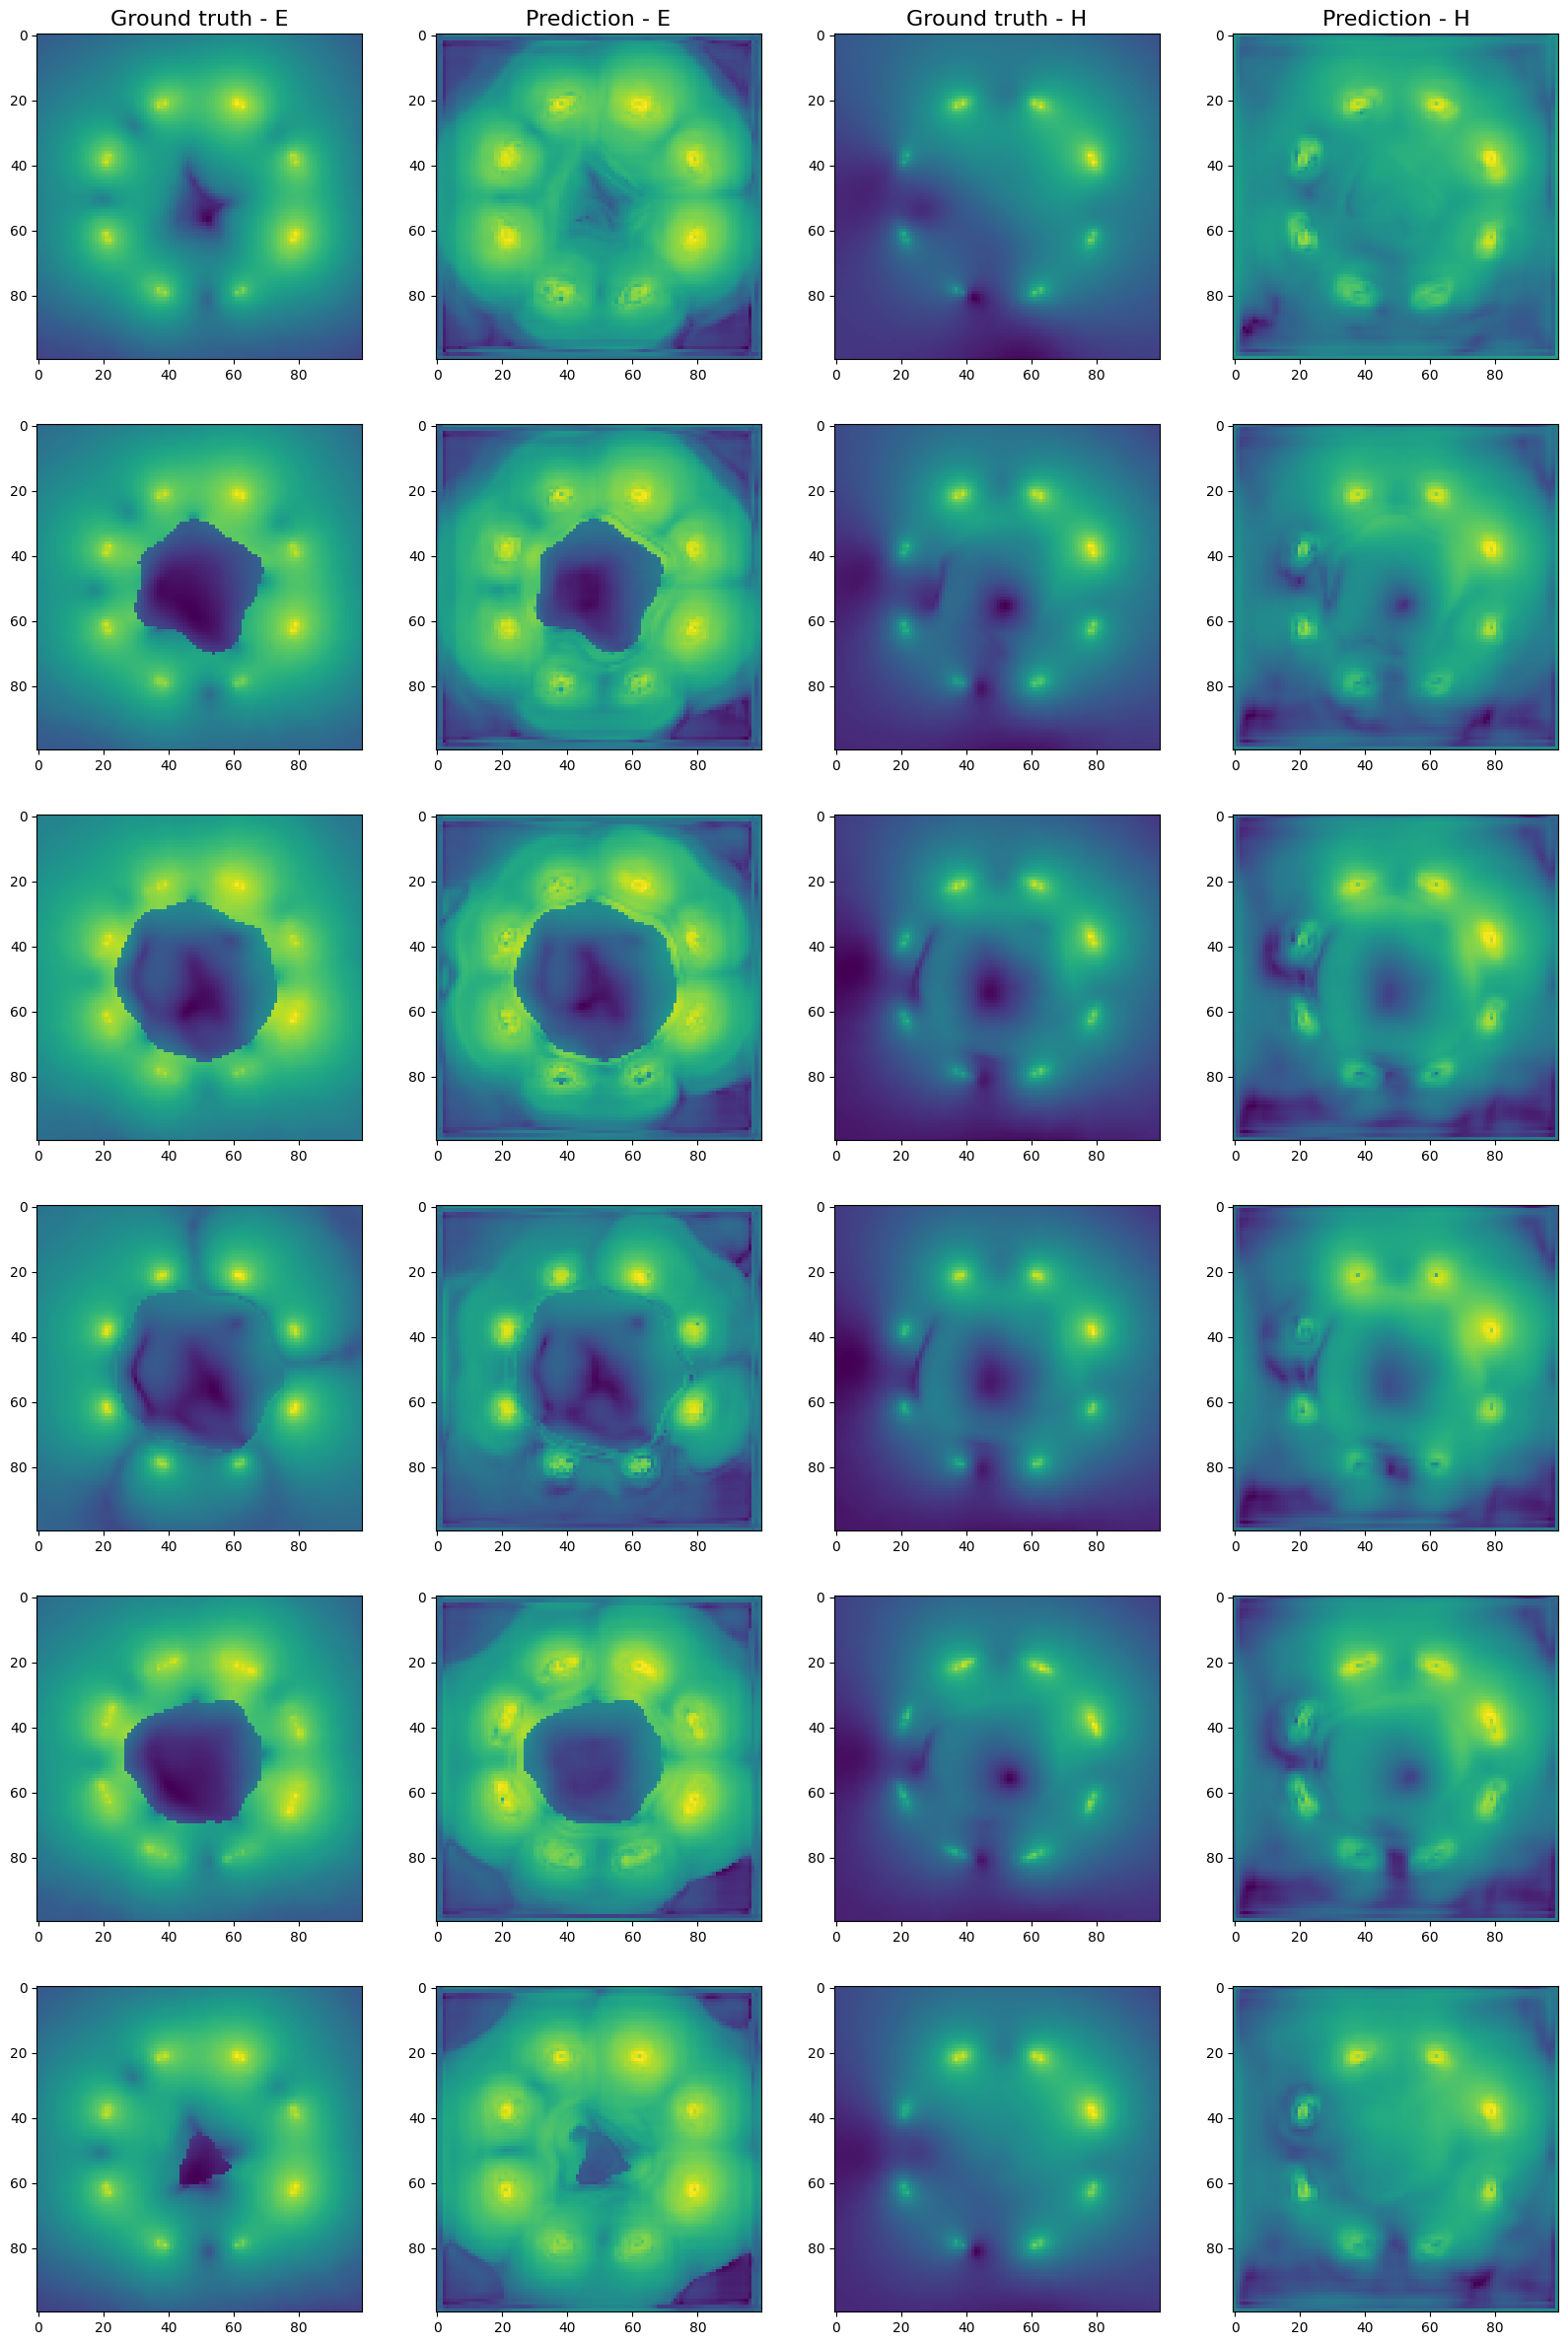

In [49]:
import matplotlib.pyplot as plt

_, axes = plt.subplots(6, 4, figsize=(20, 30))

titles = ['Ground truth - E', 'Prediction - E', 'Ground truth - H', 'Prediction - H']

for column, title in zip(axes[0], titles):
    column.set_title(title, fontsize=16)

for row in range(6):
    slice = 20 + row * 10

    gt_e = axes[row, 0].imshow(gt[0, :, :, slice], cmap='viridis', norm='log')
    pr_e = axes[row, 1].imshow(pr[0, :, :, slice], cmap='viridis', norm='log')

    gt_h = axes[row, 2].imshow(gt[1, :, :, slice], cmap='viridis', norm='log')
    pr_h = axes[row, 3].imshow(pr[1, :, :, slice], cmap='viridis', norm='log')

plt.show()